In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [14]:
df=pd.read_csv("/content/Restaurant_Branch_Performance_Dataset.csv")
df.head()


,Record_ID,Date,Day,Month,Branch,Region,Store_Type,Staff_Count,Marketing_Spend,Customers,...,Revenue,Food_Cost,Operating_Cost,Profit,Avg_Delivery_Min,Customer_Rating,Temperature_C,Humidity_Percent,Weather,Promotion
0,ST0001,2026-06-06,Saturday,June,Jaipur,North,Express,7,4977.25,172,...,66766.77,27954.29,46554.90,20211.87,29.0,4.44,20.8,70.3,Clear,NaN
1,ST0002,2026-02-10,Tuesday,February,Pune,West,Premium,14,8998.30,285,...,157230.89,63816.59,96813.95,60416.94,27.9,4.56,31.3,70.7,Clear,Loyalty Offer
2,ST0003,2026-03-07,Saturday,March,Delhi,North,Premium,16,10034.97,306,...,155811.96,54874.10,89888.91,65923.05,30.2,4.36,21.4,61.5,Clear,NaN
3,ST0004,2026-05-11,Monday,May,Mumbai,West,Standard,9,5095.84,198,...,80574.05,31429.44,53531.82,27042.23,21.7,4.65,22.9,40.4,Clear,NaN
4,ST0005,2026-01-14,Wednesday,January,Kochi,South,Express,9,6681.82,148,...,56579.89,21759.51,44376.25,12203.64,26.1,4.50,29.0,44.3,Clear,Combo Deal


In [47]:
# Restaurant Branch Performance - Complete EDA


# 2. Basic information
print("First 5 rows:")
print(df.head())

print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())
df["Promotion"] = df["Promotion"].fillna("No")

print("\nDuplicate Rows:")
print(df.duplicated().sum())

# 3. Summary statistics
print("\nSummary Statistics:")
print(df.describe())

print("\nCategorical Summary:")
print(df.describe(include="object"))



First 5 rows:
  Record_ID        Date        Day     Month  Branch Region Store_Type  \
0    ST0001  2026-06-06   Saturday      June  Jaipur  North    Express   
1    ST0002  2026-02-10    Tuesday  February    Pune   West    Premium   
2    ST0003  2026-03-07   Saturday     March   Delhi  North    Premium   
3    ST0004  2026-05-11     Monday       May  Mumbai   West   Standard   
4    ST0005  2026-01-14  Wednesday   January   Kochi  South    Express   

   Staff_Count  Marketing_Spend  Customers  ...    Revenue  Food_Cost  \
0            7          4977.25        172  ...   66766.77   27954.29   
1           14          8998.30        285  ...  157230.89   63816.59   
2           16         10034.97        306  ...  155811.96   54874.10   
3            9          5095.84        198  ...   80574.05   31429.44   
4            9          6681.82        148  ...   56579.89   21759.51   

   Operating_Cost    Profit  Avg_Delivery_Min  Customer_Rating  Temperature_C  \
0        46554.90  20

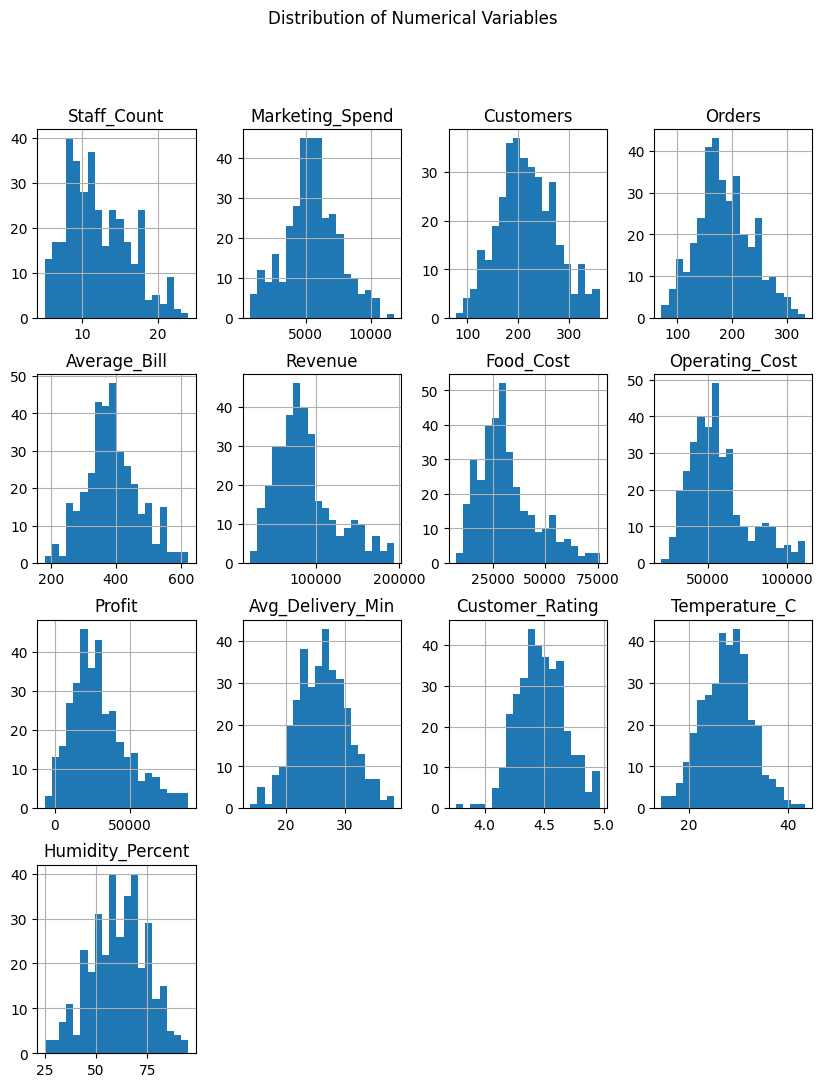

In [48]:
# 4. Distribution analysis
numeric_columns = df.select_dtypes(include="number").columns
df[numeric_columns].hist(figsize=(10, 12), bins=20)
plt.suptitle("Distribution of Numerical Variables")
plt.show()



In [49]:
# 5. Performance by Branch
print("\nPerformance by Branch:")
print(df.groupby("Branch")[[
    "Customers",
    "Revenue",
    "Profit",
    "Marketing_Spend",
    "Staff_Count",
    "Avg_Delivery_Min",
    "Customer_Rating"
]].mean())




Performance by Branch:
            Customers       Revenue        Profit  Marketing_Spend  \
Branch                                                               
Bengaluru  227.500000  90732.118696  31890.914783      5413.928478   
Delhi      213.968750  87573.869375  31385.295313      5762.632500   
Hyderabad  220.790698  88804.899535  31402.976977      5455.148372   
Jaipur     223.270833  86746.158333  30469.703333      5356.641458   
Kochi      209.062500  85574.617917  28902.036250      5660.430000   
Mumbai     213.772727  80779.248864  26580.988409      5580.095682   
Pune       214.918919  88107.489730  31265.571892      5590.567568   
Srinagar   214.730769  86746.472885  30302.915769      5413.668077   

           Staff_Count  Avg_Delivery_Min  Customer_Rating  
Branch                                                     
Bengaluru    12.847826         26.563043         4.465652  
Delhi        11.562500         25.693750         4.485625  
Hyderabad    12.279070         25.5

In [50]:
# 6. Performance by Region
print("\nPerformance by Region:")
print(df.groupby("Region")[[
    "Customers",
    "Revenue",
    "Profit",
    "Marketing_Spend",
    "Staff_Count",
    "Avg_Delivery_Min",
    "Customer_Rating"
]].mean())




Performance by Region:
         Customers       Revenue        Profit  Marketing_Spend  Staff_Count  \
Region                                                                         
North   217.651515  86946.939470  30625.960833      5477.528561    11.969697   
South   218.934307  88320.217518  30690.568102      5513.231606    12.313869   
West    214.296296  84126.716914  28720.859877      5584.879136    11.333333   

        Avg_Delivery_Min  Customer_Rating  
Region                                     
North          26.125758         4.477424  
South          25.982482         4.450803  
West           26.251852         4.487407  


In [51]:
# 7. Performance by Store Type
print("\nPerformance by Store Type:")
print(df.groupby("Store_Type")[[
    "Customers",
    "Revenue",
    "Profit",
    "Marketing_Spend",
    "Staff_Count",
    "Avg_Delivery_Min",
    "Customer_Rating"
]].mean())




Performance by Store Type:
             Customers        Revenue        Profit  Marketing_Spend  \
Store_Type                                                             
Express     161.294118   52327.164804  12742.137941      5122.663922   
Premium     298.730769  152867.313269  62890.235385      8065.562692   
Standard    224.979592   87268.667245  30630.785714      5044.901684   

            Staff_Count  Avg_Delivery_Min  Customer_Rating  
Store_Type                                                  
Express        7.960784         26.171569         4.465000  
Premium       17.596154         26.400000         4.458654  
Standard      12.540816         25.981122         4.474388  


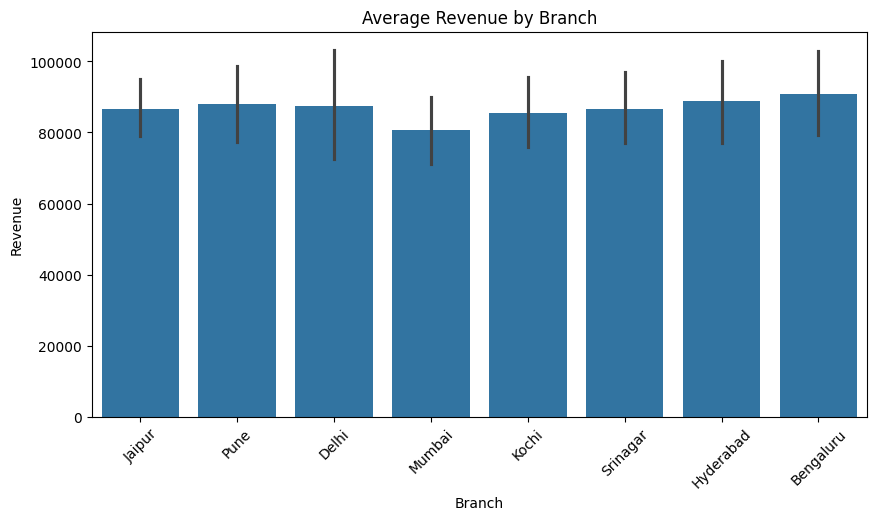

In [52]:
# 8. Revenue by Branch
plt.figure(figsize=(10, 5))
sns.barplot(df, x="Branch", y="Revenue")
plt.title("Average Revenue by Branch")
plt.xticks(rotation=45)
plt.show()



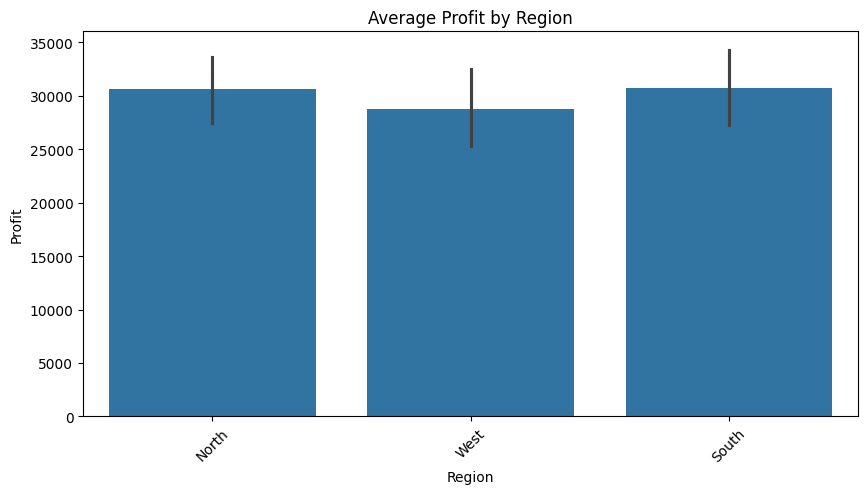

In [53]:
# 9. Profit by Region
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Region", y="Profit")
plt.title("Average Profit by Region")
plt.xticks(rotation=45)
plt.show()



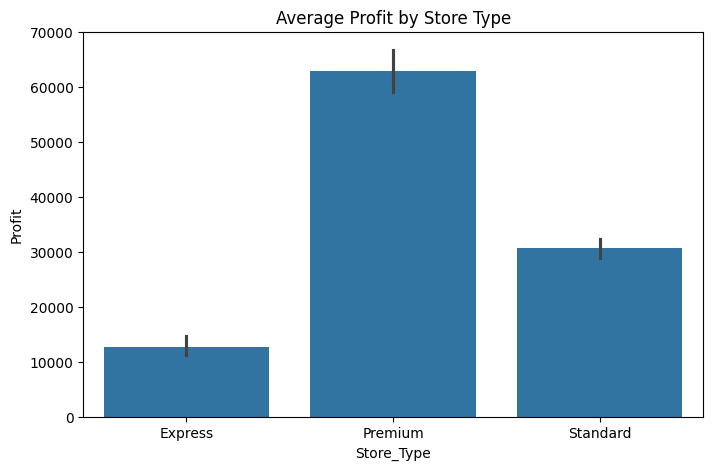

In [54]:
# 10. Profit by Store Type
plt.figure(figsize=(8, 5))
sns.barplot(data=df, x="Store_Type", y="Profit")
plt.title("Average Profit by Store Type")
plt.show()




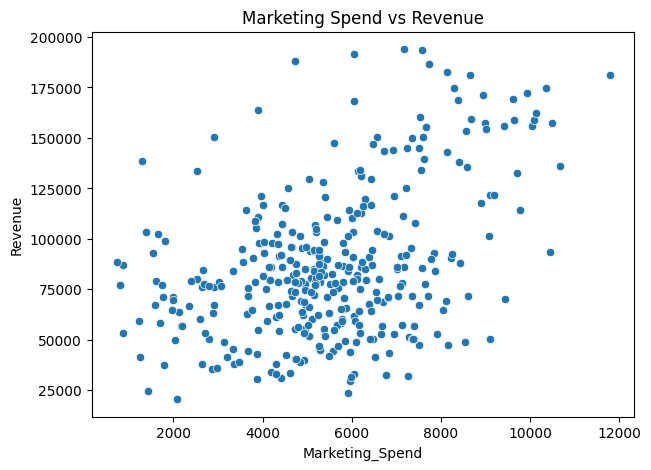

In [55]:
# 11. Marketing Spend vs Revenue
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Marketing_Spend", y="Revenue")
plt.title("Marketing Spend vs Revenue")
plt.show()



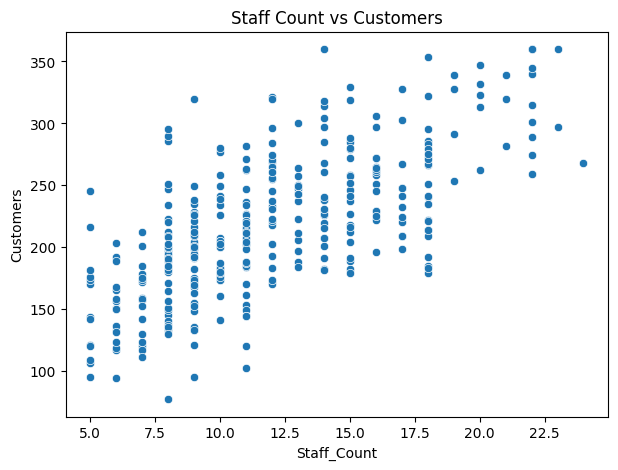

In [56]:
# 12. Staff Count vs Customers
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Staff_Count", y="Customers")
plt.title("Staff Count vs Customers")
plt.show()



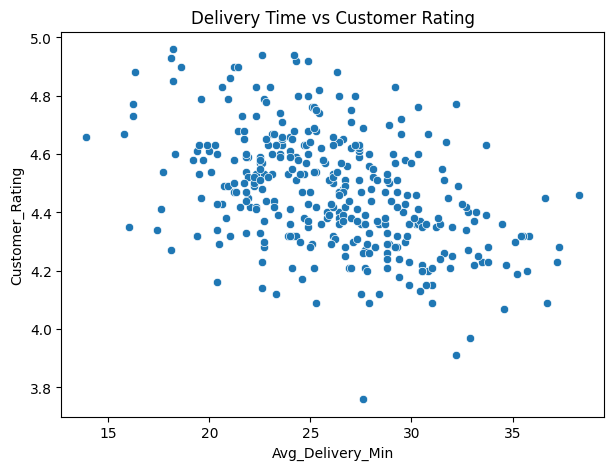

In [57]:
# 13. Delivery Time vs Customer Rating
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="Avg_Delivery_Min", y="Customer_Rating")
plt.title("Delivery Time vs Customer Rating")
plt.show()




Correlation Matrix:
                  Staff_Count  Marketing_Spend  Customers    Orders  \
Staff_Count          1.000000         0.283133   0.689404  0.672229   
Marketing_Spend      0.283133         1.000000   0.405114  0.416349   
Customers            0.689404         0.405114   1.000000  0.980333   
Orders               0.672229         0.416349   0.980333  1.000000   
Average_Bill         0.521755         0.332017   0.532218  0.522090   
Revenue              0.695114         0.431136   0.876361  0.857756   
Food_Cost            0.680174         0.404598   0.844339  0.827561   
Operating_Cost       0.788468         0.485469   0.855797  0.840780   
Profit               0.559281         0.350265   0.835993  0.815261   
Avg_Delivery_Min    -0.182412         0.101244   0.183832  0.187107   
Customer_Rating      0.084284        -0.062082  -0.048383 -0.051216   
Temperature_C        0.083207         0.058402   0.002476  0.020274   
Humidity_Percent    -0.017823        -0.045808  -0.10052

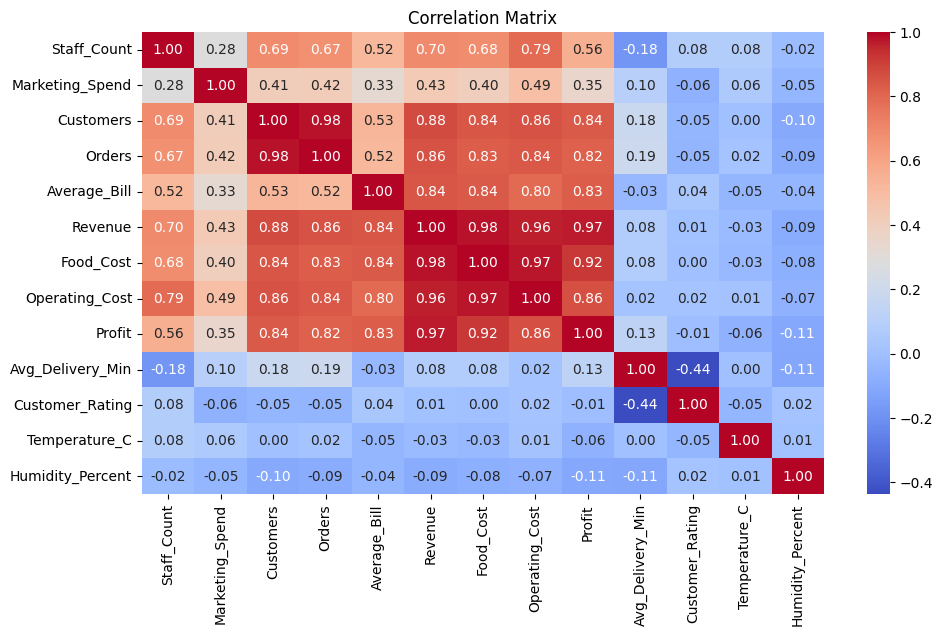

In [58]:
# 14. Correlation matrix
correlation = df.select_dtypes(include="number").corr()

print("\nCorrelation Matrix:")
print(correlation)

plt.figure(figsize=(11, 6))
sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

# 15. Strongest correlations with Revenue
print("\nCorrelation with Revenue:")
print(correlation["Revenue"].sort_values(ascending=False))

# 16. Strongest correlations with Profit
print("\nCorrelation with Profit:")
print(correlation["Profit"].sort_values(ascending=False))

# 17. Strongest correlations with Customers
print("\nCorrelation with Customers:")
print(correlation["Customers"].sort_values(ascending=False))